In [2]:
from pathlib import Path
import torch

# Base project directory
BASE = Path.home() / "MyWork" / "LoRA_Reproduction"

# Task directories
RTE_DIR = BASE / "nlu" / "rte"
LOGS_DIR = BASE / "results" / "logs"

RTE_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

print("RTE directory:", RTE_DIR)
print("Logs directory:", LOGS_DIR)

# GPU check
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

RTE directory: /home/shahd.baloum/MyWork/LoRA_Reproduction/nlu/rte
Logs directory: /home/shahd.baloum/MyWork/LoRA_Reproduction/results/logs
CUDA available: True
GPU: NVIDIA L4


In [8]:
from datasets import load_dataset

dataset = load_dataset(
    "nyu-mll/glue",
    "rte"
)

print(dataset)

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

rte/train-00000-of-00001.parquet:   0%|          | 0.00/584k [00:00<?, ?B/s]

rte/validation-00000-of-00001.parquet:   0%|          | 0.00/69.0k [00:00<?, ?B/s]

rte/test-00000-of-00001.parquet:   0%|          | 0.00/621k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2490 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/277 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3000
    })
})


In [10]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(tokenized_dataset)

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/277 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 3000
    })
})


In [12]:
import sys
import site

USER_SITE = site.getusersitepackages()

if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

import peft

print("PEFT version:", peft.__version__)

PEFT version: 0.19.1


In [13]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

model = get_peft_model(model, lora_config)

model.to("cuda")

model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [15]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = (preds == labels).mean()
    return {"accuracy": accuracy}

In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=str(RTE_DIR / "output"),

    learning_rate=5e-4,
    num_train_epochs=10,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    report_to="none"
)

In [19]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [20]:
model.config.use_cache = False

train_result = trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.706963,0.666254,0.631769
2,0.695794,0.700441,0.472924
3,0.671904,0.691256,0.527076
4,0.671317,0.660359,0.660650
5,0.644158,0.612662,0.667870
6,0.619149,0.559555,0.714801
7,0.422678,0.622577,0.718412
8,0.449239,0.553833,0.732852
9,0.483472,0.572868,0.743682
10,0.425191,0.594296,0.740072


In [21]:
import json

results = {
    "task": "RTE",
    "model": "roberta-base + LoRA",
    "best_accuracy": 0.7437,
    "epochs": 10,
    "learning_rate": 5e-4,
    "batch_size": 16
}

with open(LOGS_DIR / "rte_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("RTE results saved!")

RTE results saved!


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

RESULTS_DIR = Path.cwd() / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

epochs = list(range(1, 11))

training_loss = [
    0.706963,
    0.695794,
    0.671904,
    0.671317,
    0.644158,
    0.619149,
    0.422678,
    0.449239,
    0.483472,
    0.425191,
]

validation_loss = [
    0.666254,
    0.700441,
    0.691256,
    0.660359,
    0.612662,
    0.559555,
    0.622577,
    0.553833,
    0.572868,
    0.594296,
]

accuracy_scores = [
    0.631769,
    0.472924,
    0.527076,
    0.660650,
    0.667870,
    0.714801,
    0.718412,
    0.732852,
    0.743682,
    0.740072,
]

results_df = pd.DataFrame({
    "epoch": epochs,
    "training_loss": training_loss,
    "validation_loss": validation_loss,
    "validation_accuracy": accuracy_scores,
})

display(results_df)

,epoch,training_loss,validation_loss,validation_accuracy
0,1,0.706963,0.666254,0.631769
1,2,0.695794,0.700441,0.472924
2,3,0.671904,0.691256,0.527076
3,4,0.671317,0.660359,0.660650
4,5,0.644158,0.612662,0.667870
5,6,0.619149,0.559555,0.714801
6,7,0.422678,0.622577,0.718412
7,8,0.449239,0.553833,0.732852
8,9,0.483472,0.572868,0.743682
9,10,0.425191,0.594296,0.740072


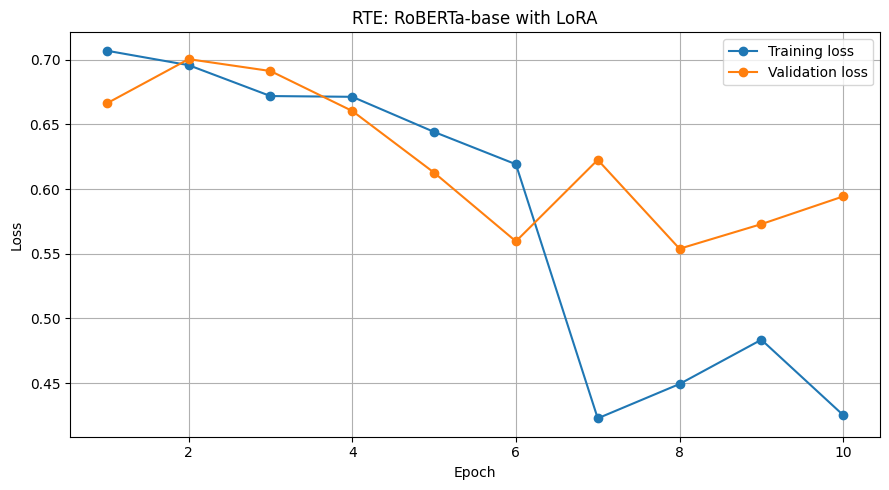

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/rte_loss_curve.png


In [2]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss",
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RTE: RoBERTa-base with LoRA")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "rte_loss_curve.png"

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", loss_plot_path)

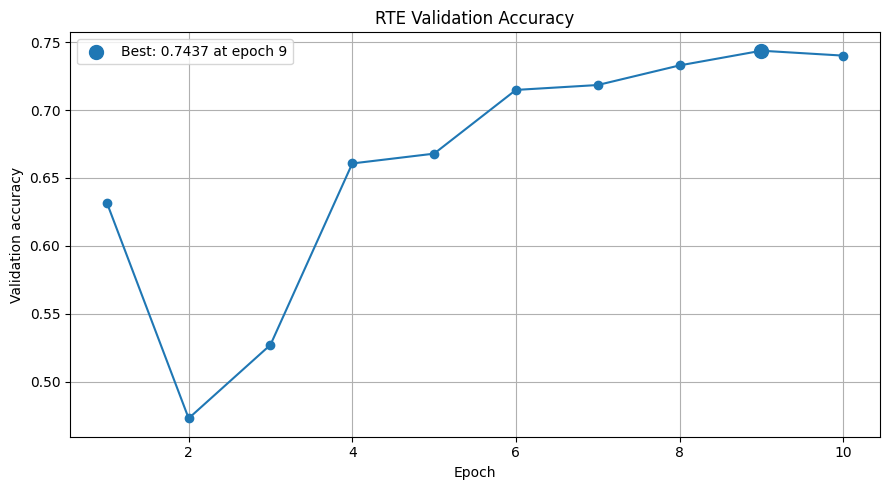

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/rte_accuracy_curve.png


In [3]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    accuracy_scores,
    marker="o",
)

best_epoch = epochs[
    accuracy_scores.index(max(accuracy_scores))
]

best_accuracy = max(accuracy_scores)

plt.scatter(
    [best_epoch],
    [best_accuracy],
    s=100,
    label=(
        f"Best: {best_accuracy:.4f} "
        f"at epoch {best_epoch}"
    ),
)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("RTE Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_plot_path = RESULTS_DIR / "rte_accuracy_curve.png"

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", accuracy_plot_path)

In [4]:
rte_results = {
    "task": "RTE",
    "model": "roberta-base",
    "method": "LoRA",
    "best_validation_accuracy": best_accuracy,
    "best_epoch": best_epoch,
    "final_epoch_accuracy": accuracy_scores[-1],
    "num_train_epochs": 10,
    "learning_rate": 5e-4,
    "lora_rank": 8,
    "lora_alpha": 16,
    "target_modules": ["query", "value"],
    "trainable_parameters": 887042,
    "trainable_percentage": 0.7066,
}

metrics_path = RESULTS_DIR / "rte_results.json"

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        rte_results,
        file,
        indent=2,
    )

results_df.to_csv(
    RESULTS_DIR / "rte_epoch_history.csv",
    index=False,
)

print("Saved:", metrics_path)

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/rte_results.json
